# Correcting z′-band Fringing in INT/WFC Images

This notebook explains how to remove the fringing from your z′-band science frames. It is a
guide, not a pipeline: the code snippets show the key operations in outline, and **the job is to
write your own implementation** that runs on your data.

## What is fringing?

If you display one of your z′-band science frames, you will see a pattern of wavy bright and dark
ripples across the sky background, a bit like an oil slick on water. This is **fringing**, and it
is an interference effect inside the CCD itself:

- The night-sky background in the far red is dominated by **emission lines of the OH radical**
  (airglow) in the upper atmosphere. Unlike starlight, this light is concentrated in narrow
  spectral lines.
- The WFC's CCDs are *thinned* chips, and near-infrared photons can traverse the silicon and
  reflect internally. Light reflected within the chip interferes with itself, constructively or
  destructively depending on the ratio of the silicon thickness to the wavelength.
- The chip thickness varies by tiny amounts (of order the wavelength of light!) across the
  detector, so the interference condition changes from place to place — producing the ripple
  pattern. In i′ the effect is present but weak; in z′ it is strong (typically a few per cent of
  the sky level for the WFC), because the OH lines are stronger and the silicon is more
  transparent at these wavelengths.

Two properties of fringing drive the whole correction strategy:

1. **The pattern is fixed.** It is set by the physical structure of the CCD, so the *shape* of the
   fringe pattern is the same in every frame, night after night.
2. **The amplitude varies.** The OH airglow brightness changes on timescales of tens of minutes,
   so the *strength* of the pattern differs from frame to frame.

So the plan is: build one high-quality **master fringe map** of the pattern, then for each science
frame find the single number by which to scale it before subtracting.

> ⚠️ **Fringing is additive, not multiplicative.** It is extra sky signal added on top of your
> image; it does not modulate the light of your stars (starlight is broadband, so its
> interference effects average out). That means we **subtract** a scaled fringe map. Never try to
> divide it out, and never let fringes contaminate your flat field.

## Roadmap

1. Build the master fringe map from the dithered blank-sky frames.
2. Choose a "bright fringe" box and a "dark fringe" box on the detector.
3. For each science frame, measure the fringe amplitude from those two boxes, scale the master
   map, and subtract.
4. Check your results.
5. *(Extension)* A more robust method: fit the whole image against the map with sigma clipping.


## 1. Building the master fringe map

### Why the observations were taken the way they were

The blank-sky frames were taken **near the target, just after dusk astronomical twilight** (they
can equally be taken just before dawn astronomical twilight). The timing matters: during twilight
the sky is dominated by scattered sunlight, which is a smooth continuum and fringes only weakly.
Once astronomical twilight ends, the narrow OH airglow lines dominate the z′ sky and the fringes
show maximum contrast — and taking the frames right at that boundary costs the minimum of prime
observing time.

The pointings are **dithered** (offset by tens of arcseconds between exposures) so that every star
lands on different pixels in different frames. That is what lets us remove the stars *without ever
having to find them*: at any given pixel, a star is present in at most one or two frames out of
many, so a sigma-clipped median straight down the unaligned stack rejects it.

### The recipe

1. **Bias-subtract and flat-field each sky frame**, identically to how you calibrate the science
   frames — the map must be built from frames reduced exactly the same way as the frames it will
   correct.
2. **Normalise each frame by its own median sky level**, so frames taken at different sky
   brightnesses carry equal weight.
3. **Median-combine the stack *without aligning the frames***, with sigma clipping to reject the
   dithered-away stars.
4. **Subtract the median of the combined image**, leaving a zero-mean fringe pattern: positive on
   bright fringes, negative on dark fringes, zero on average.

In outline, the heart of it looks like this (using `astropy.stats.sigma_clip`):

```python
normalised = [frame / np.median(frame) for frame in calibrated_sky_frames]

cube = np.stack(normalised)                       # shape (n_frames, ny, nx)
clipped = sigma_clip(cube, sigma=3.0, axis=0)     # stars reject themselves
master_fringe = np.ma.median(clipped, axis=0).filled(np.nan)
master_fringe -= np.nanmedian(master_fringe)      # zero-mean
```

The map ends up in fractional units (fringe signal relative to sky level), but the units don't
matter — the per-frame scale factor you fit later absorbs them automatically.

### What success looks like

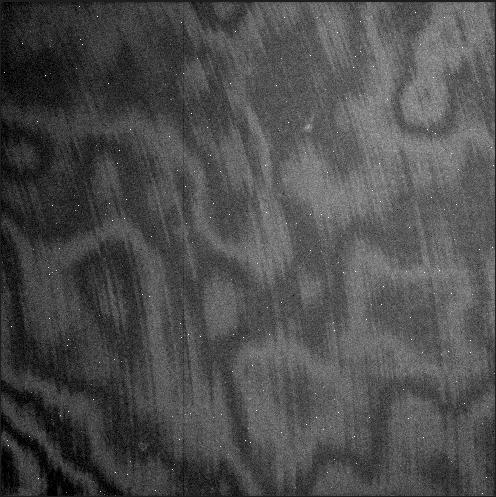

*Example master fringe map from INT/WFC z′-band data (zscale stretch). The swirled ripple pattern is the fringing; note there are no stars left in the map — the dithering and sigma-clipped median have removed them.*

Check your own map against this. Two things to verify:

- **No star residuals.** If you can see faint donuts, the dither offsets were too small relative
  to the PSF size or you have too few frames for the clipping to work.
- **Sensible amplitude.** The values should be a small fraction of unity — print the 5th and 95th
  percentiles; a few per cent is typical for the WFC in z′.


## 2. Choosing the bright-fringe and dark-fringe boxes

To know how strongly the fringes appear in a given science frame, compare the sky level in a
region sitting on a **bright** fringe with a region sitting on a **dark** fringe. The difference
between the two is the fringe amplitude — and, crucially, taking a *difference* cancels the
overall sky background level, which also changes from frame to frame.

Guidelines for choosing the boxes:

- **Choose them on the master map**, where the fringes are cleanest: one box lying entirely on a
  strong bright fringe, one entirely on a strong dark fringe. The further apart the two medians,
  the better the leverage on the scale factor.
- **Make them big** — at least ~100×100 pixels if the fringe width allows. Bigger boxes mean the
  median is less noisy. It is fine (and often necessary) for a box to be elongated to follow a
  fringe.
- **They must contain no stars in the science frames.** Display one of your science frames and
  check. Remember your PSFs are heavily defocused donuts, so give stars a wide berth. Because
  this is a transit time series the telescope does not dither — the stars sit on essentially the
  same pixels all night — so check the first and last frames of the night and you are done.
- Avoid the detector edges and any bad columns.

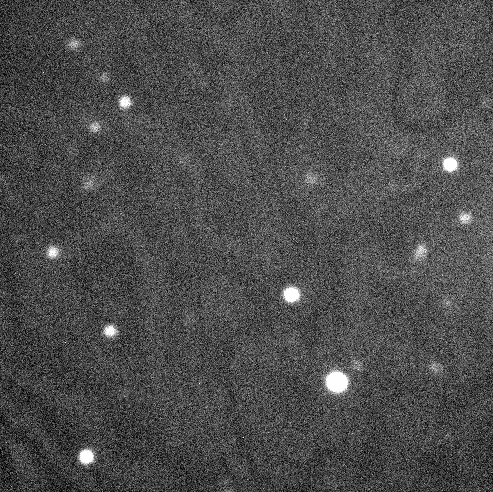

*Example z′-band science frame (zscale stretch). The fringes are visible as faint ripples in the sky background between the stars — the same pattern as the master map, at much lower contrast because the stars and sky noise sit on top. The boxes must sit on strong fringes in the master map while staying well clear of every star seen here.*

A practical way to work: display the master map and a science frame side by side with your
candidate boxes drawn on both (`matplotlib.patches.Rectangle`), and iterate on the coordinates
until you are happy. A NumPy slice is a convenient way to define a box once and reuse it on any
image:

```python
bright_box = np.s_[1250:1400, 300:500]   # rows (y), then columns (x)
dark_box   = np.s_[1550:1700, 550:750]

np.median(image[bright_box])             # works on any frame or on the map
```


## 3. The two-box correction

For an image \(I\) and the master map \(F\), define the fringe amplitude as

$$ A(I) \; = \; \mathrm{median}\big(I[\mathrm{bright}]\big) \; - \; \mathrm{median}\big(I[\mathrm{dark}]\big) $$

The sky background level appears in both boxes equally, so it cancels in the difference — what is
left is purely the strength of the fringing. The scale factor for a science frame is then simply

$$ s \; = \; \frac{A(\mathrm{science})}{A(\mathrm{map})} $$

and the corrected frame is \( I - s\,F \). Use the **median** (not the mean) inside the boxes:
it gives some protection against the odd cosmic ray or bad pixel.

The whole method is essentially four lines:

```python
def fringe_amplitude(image, bright_box, dark_box):
    return np.median(image[bright_box]) - np.median(image[dark_box])

scale = (fringe_amplitude(science, bright_box, dark_box)
         / fringe_amplitude(master_fringe, bright_box, dark_box))
corrected = science - scale * master_fringe
```

Apply this to every science frame of the night, each with its own scale factor. Two habits worth
adopting when you write this up as part of your reduction:

- **Record the scale factor** for each frame (e.g. as a `FRNGSCL` keyword in the output FITS
  header), so the correction is traceable and you can plot it later.
- **Correct after bias and flat, before photometry** — same place in the chain as where the map
  was built.


## 4. Checking your results

Three checks, in increasing order of importance:

1. **Look at the images.** Display a frame before and after correction *with the same zscale
   stretch* (if you let the display auto-stretch each image, the comparison tells you nothing).
   After correction the sky background should look flat.
2. **Plot the scale factor against time.** The OH airglow varies smoothly on timescales of tens
   of minutes, so you should see a smoothly varying curve across the night. A single frame
   jumping far off the trend deserves a look — a satellite trail or cosmic ray in one of your
   boxes, for instance. It is also interesting to compare this curve with the raw sky level
   (median of each frame): do they track each other?
3. **Compare the photometry.** Run your aperture photometry on corrected and uncorrected frames
   and compare the scatter of the differential light curves. Fringing hurts photometry because
   your target and comparison stars sit on *different* parts of the fringe pattern, so as the OH
   brightness varies, their sky backgrounds vary differently. This is the number that actually
   matters — quantify the improvement in mmag.


## 5. Extension: a whole-image robust fit

The two-box method uses only a few thousand pixels. You can instead use (nearly) **every sky
pixel in the frame**: since the corrected image should contain no trace of the map, the pixel
values of the science frame, plotted against the pixel values of the master map, should follow a
straight line — slope = fringe scale factor, intercept = sky level.

The complication is stars: their pixels lie far off that line. Rather than finding the stars
(your defocused donut PSFs would defeat most star finders anyway), simply **fit iteratively with
sigma clipping**: fit a line, discard the pixels more than 3σ from it, refit. After two or three
iterations the star pixels — along with cosmic rays and bad pixels — have rejected themselves,
without your ever needing to know where the stars are.

```python
def fringe_scale_fit(image, fringe_map, sigma=3.0, n_iter=3, subsample=4):
    # subsample thins the pixel grid for speed; 1/16th of a WFC chip
    # is still ~500k pixels, far more than enough
    x = fringe_map[::subsample, ::subsample].ravel()
    y = image[::subsample, ::subsample].ravel()
    good = np.isfinite(x) & np.isfinite(y)
    for _ in range(n_iter):
        slope, intercept = np.polyfit(x[good], y[good], 1)
        residuals = y - (slope * x + intercept)
        good = good & (np.abs(residuals) < sigma * np.std(residuals[good]))
    return slope, intercept
```

This is what the "LAD fit" in the group's older ULTRACAM pipeline was aiming at, minus the manual
star catalogues it relied on. A good test of both your implementations: compute the scale factor
both ways for a sample of frames across the night and plot one against the other — they should
scatter tightly around the 1:1 line.


## Checklist

- **Order of operations:** bias → flat → *fringe subtraction* → photometry. The master map must
  be built from frames calibrated identically to the science frames.
- **Subtract, never divide.** Fringing is additive sky signal. Do not build it into your flat
  field, and check that your flat (usually built from twilight or dome exposures) is not itself
  contaminated by fringes.
- **The boxes must stay star-free.** Since the telescope is not dithered during a transit
  sequence this is easy to verify — but do verify, on both the first and last frames.
- **One map per run is usually fine.** The pattern is fixed by the CCD; only the amplitude
  changes, and the per-frame scale factor handles that.
- **Judge success on the photometry**, not just on how the images look.

### Things to try once your code works

1. Deliberately move the bright box so it overlaps a star's donut and rerun. Describe what
   happens to the scale-factor curve, and explain why.
2. Compare the scale-factor curve with the median sky level of each frame through the night. Do
   they move together? Would you expect them to, exactly?
3. How large was the fringing effect on your target's photometry, in mmag?
